In [ ]:
# subset of the glia cluster was created and topic modelling performed as for the whole embryo dataset

# 1 topic modelling output

In [2]:
import pickle
outDir = '/staging/leuven/stg_00171/Mark/IX_XII_MP_integration/paper_subsets/'
infile = open(outDir + "G_cistopic_obj_subset.pkl", 'rb')
cistopic_obj = pickle.load(infile)
infile.close()

In [69]:
outDir = '/staging/leuven/stg_00171/Mark/IX_XII_MP_integration/paper_subsets/'
print(outDir + "G_cistopic_obj_subset.pkl")

/staging/leuven/stg_00171/Mark/IX_XII_MP_integration/paper_subsets/G_cistopic_obj_subset.pkl


In [1]:
outDir = '/staging/leuven/stg_00171/Mark/IX_XII_MP_integration/paper_subsets/topic_modelling_G/'

import pickle
import glob

# import topic modelling files
file_paths = sorted(glob.glob(outDir + "Topic*.pkl"))

# Load each file into a list
topic_list = []
for file in file_paths:
    with open(file, 'rb') as f:
        topic_list.append(pickle.load(f))

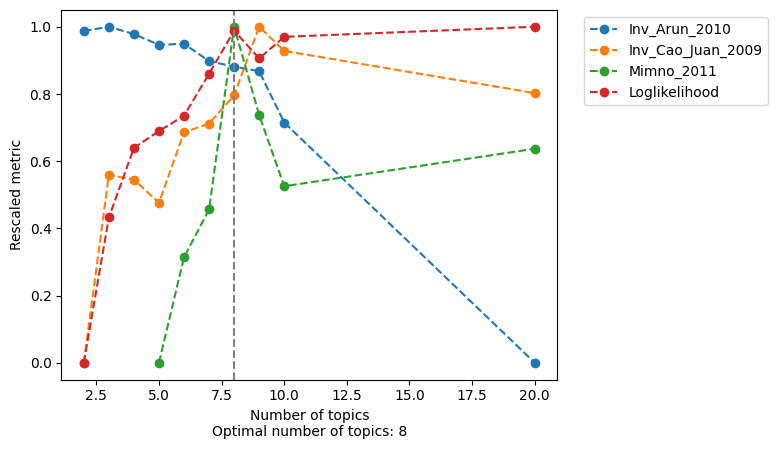

In [40]:
from pycisTopic.lda_models import evaluate_models
model = evaluate_models(
    topic_list,
    select_model = 8,
    return_model = True
)

# 2 harmony integration, clustering, dimensionality reduction

In [41]:
cistopic_obj.add_LDA_model(model)

In [42]:
from pycisTopic.clust_vis import harmony
harmony(cistopic_obj, 
        'sample_id',
        scale = True,
        random_state = 33,
        max_iter_harmony=30)

2026-01-06 15:35:07,000 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...


2026-01-06 15:35:07,000 harmonypy    INFO     Computing initial centroids with sklearn.KMeans...


2026-01-06 15:35:07,079 - harmonypy - INFO - sklearn.KMeans initialization complete.


2026-01-06 15:35:07,079 harmonypy    INFO     sklearn.KMeans initialization complete.


2026-01-06 15:35:07,081 - harmonypy - INFO - Iteration 1 of 30


...

2026-01-06 15:35:07,386 harmonypy    INFO     Iteration 8 of 30


2026-01-06 15:35:07,451 - harmonypy - INFO - Iteration 9 of 30


2026-01-06 15:35:07,451 harmonypy    INFO     Iteration 9 of 30


2026-01-06 15:35:07,483 - harmonypy - INFO - Converged after 9 iterations


2026-01-06 15:35:07,483 harmonypy    INFO     Converged after 9 iterations


In [43]:
from pycisTopic.clust_vis import (
    find_clusters,
    run_umap,
    run_tsne,
    plot_metadata,
    plot_topic,
    cell_topic_heatmap
)

In [44]:
find_clusters(
    cistopic_obj,
    harmony = True,
    target  = 'cell',
    k = 10,
    res = [0.1, 0.2, 0.3, 0.4, 0.5],
    prefix = 'pycisTopic_',
    scale = True,
    split_pattern = '-'
)

2026-01-06 15:35:10,019 cisTopic     INFO     Finding neighbours
Columns ['pycisTopic_leiden_10_0.1'] will be overwritten
Columns ['pycisTopic_leiden_10_0.2'] will be overwritten
Columns ['pycisTopic_leiden_10_0.3'] will be overwritten
Columns ['pycisTopic_leiden_10_0.4'] will be overwritten
Columns ['pycisTopic_leiden_10_0.5'] will be overwritten


In [45]:
run_umap(
    cistopic_obj,
    target  = 'cell', scale=True, 
    reduction_name = 'UMAP_HARM',
    harmony=True,
    verbose=False
)

2026-01-06 15:35:11,287 cisTopic     INFO     Running UMAP


/data/leuven/347/vsc34794/miniconda3/envs/scenicplus/lib/python3.11/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


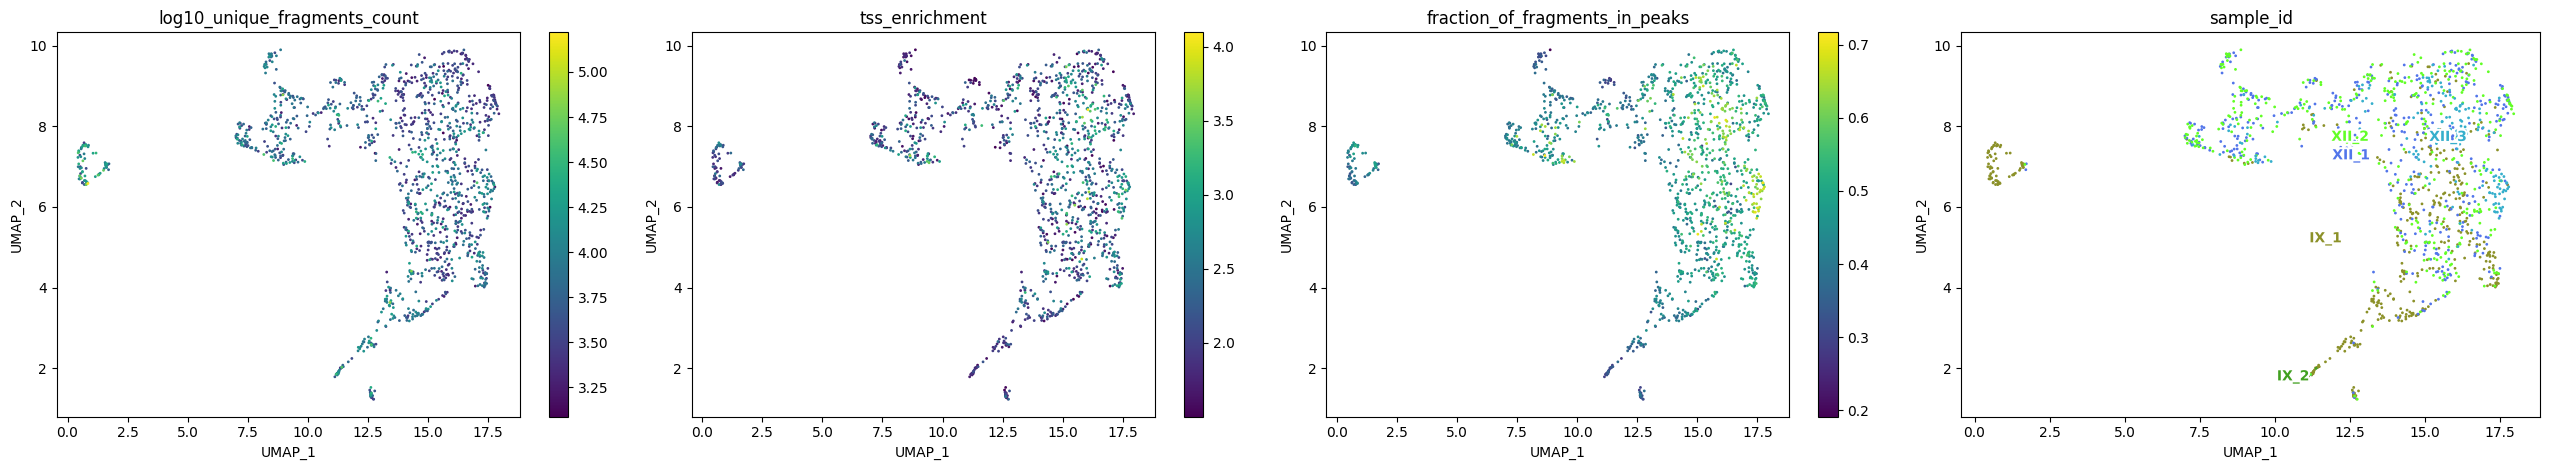

In [46]:
plot_metadata(
    cistopic_obj,
    reduction_name='UMAP_HARM',
    variables=['log10_unique_fragments_count', 'tss_enrichment', 'fraction_of_fragments_in_peaks', 'sample_id'],
    target='cell', num_columns=4,
    text_size=10,
    dot_size=1)

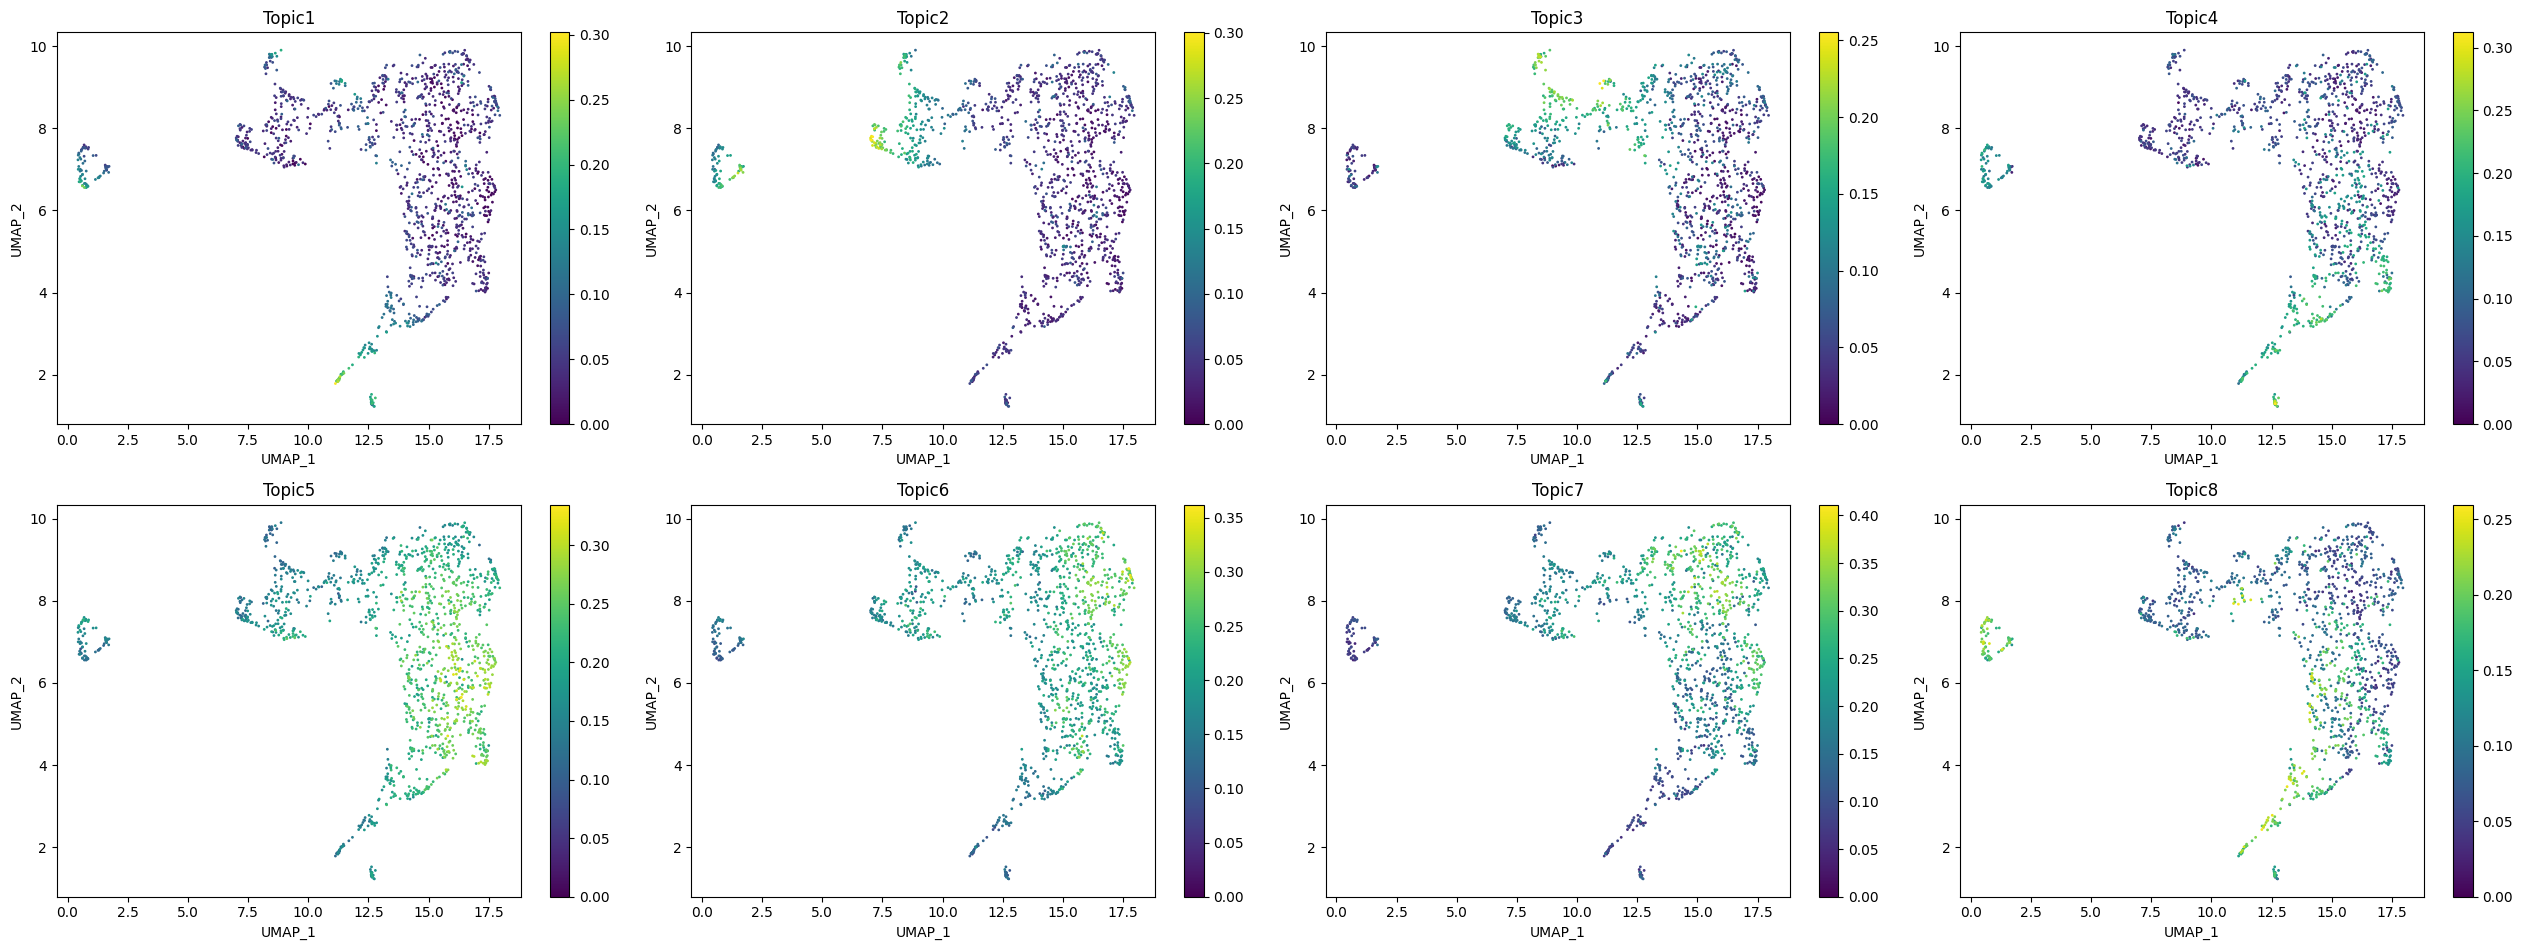

In [47]:
plot_topic(
    cistopic_obj,
    reduction_name = 'UMAP_HARM',
    target = 'cell',
    num_columns=4,
    dot_size=1
)

In [48]:
variable = 'coarse_anno'

annot_dict = {}
for resolution in [0.1, 0.2, 0.3, 0.4, 0.5]:
    annot_dict[f"pycisTopic_leiden_10_{resolution}"] = {}
    for cluster in set(cistopic_obj.cell_data[f"pycisTopic_leiden_10_{resolution}"]):
        counts = cistopic_obj.cell_data.loc[
            cistopic_obj.cell_data.loc[cistopic_obj.cell_data[f"pycisTopic_leiden_10_{resolution}"] == cluster].index,
            variable].value_counts()
        annot_dict[f"pycisTopic_leiden_10_{resolution}"][cluster] = f"{counts.index[counts.argmax()]}({cluster})"


In [49]:
for resolution in [0.1, 0.2, 0.3, 0.4, 0.5]:
    cistopic_obj.cell_data[f'pycisTopic_leiden_10_{resolution}'] = [
        annot_dict[f'pycisTopic_leiden_10_{resolution}'][x] for x in cistopic_obj.cell_data[f'pycisTopic_leiden_10_{resolution}'].tolist()
    ]


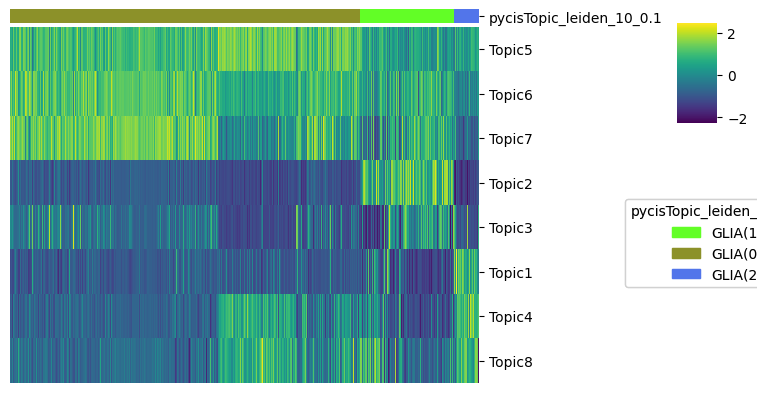

In [50]:
cell_topic_heatmap(
    cistopic_obj,
    variables = ['pycisTopic_leiden_10_0.1'],
    scale = True,
    legend_loc_x = 1.0,
    legend_loc_y = -1.2,
    legend_dist_y = -1,
    figsize = (8, 5)
)


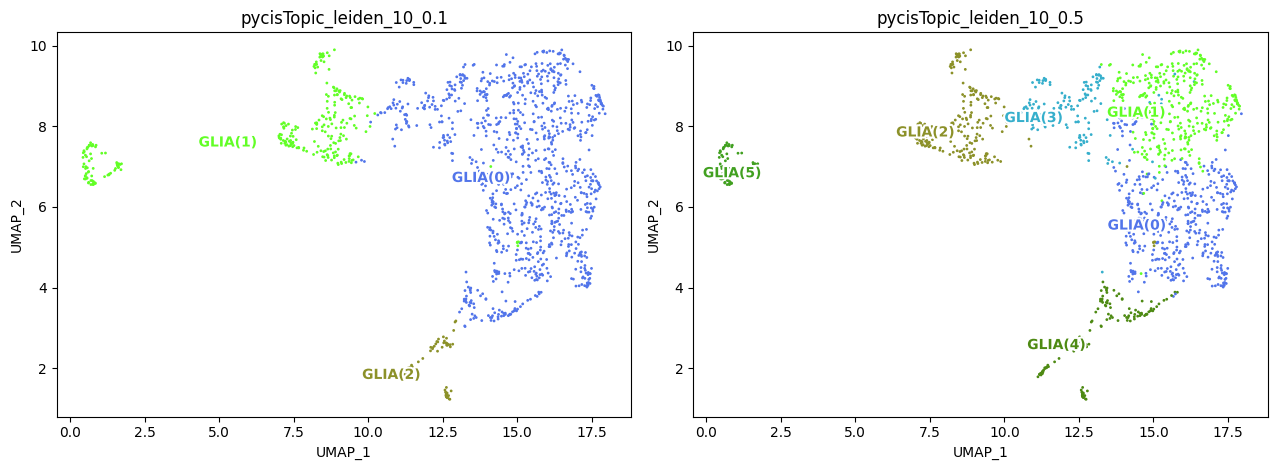

In [51]:
plot_metadata(
    cistopic_obj,
    reduction_name='UMAP_HARM',
    variables=['pycisTopic_leiden_10_0.1', 'pycisTopic_leiden_10_0.5'],
    target='cell', num_columns=4,
    text_size=10,
    dot_size=1)

# 3 topic binarization and QC

In [24]:
from pycisTopic.topic_binarization import binarize_topics

In [25]:
region_bin_topics_top_2k = binarize_topics(
    cistopic_obj, method='ntop', ntop = 2000,
    plot=False, num_columns=5
)


In [26]:
region_bin_topics_otsu = binarize_topics(
    cistopic_obj, method='otsu',
    plot=False, num_columns=5
)


In [27]:
binarized_cell_topic = binarize_topics(
    cistopic_obj,
    target='cell',
    method='li',
    plot=False,
    num_columns=5, nbins=100)


In [28]:
from pycisTopic.topic_qc import compute_topic_metrics, plot_topic_qc, topic_annotation
import matplotlib.pyplot as plt
from pycisTopic.utils import fig2img

In [29]:
topic_qc_metrics = compute_topic_metrics(cistopic_obj)

In [30]:
fig_dict={}
fig_dict['CoherenceVSAssignments']=plot_topic_qc(topic_qc_metrics, var_x='Coherence', var_y='Gini_index', plot=False, return_fig=True)


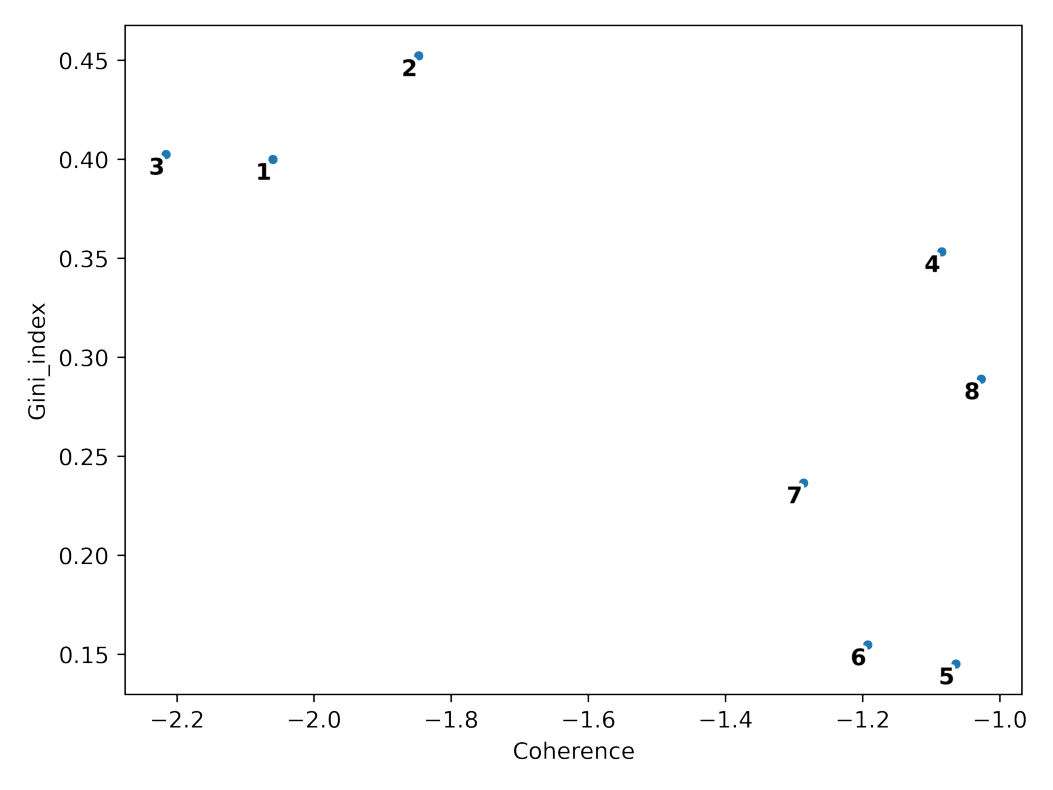

In [31]:
# Plot topic stats in one figure
fig=plt.figure(figsize=(40, 43))
i = 1
for fig_ in fig_dict.keys():
    plt.subplot(2, 3, i)
    img = fig2img(fig_dict[fig_]) #To convert figures to png to plot together, see .utils.py. This converts the figure to png.
    plt.imshow(img)
    plt.axis('off')
    i += 1
plt.subplots_adjust(wspace=0, hspace=-0.70)
plt.show()

In [32]:
fig_dict={}
fig_dict['CoherenceVSAssignments']=plot_topic_qc(topic_qc_metrics, var_x='Coherence', var_y='Log10_Assignments', var_color='Gini_index', plot=False, return_fig=True)
fig_dict['AssignmentsVSCells_in_bin']=plot_topic_qc(topic_qc_metrics, var_x='Log10_Assignments', var_y='Cells_in_binarized_topic', var_color='Gini_index', plot=False, return_fig=True)
fig_dict['CoherenceVSCells_in_bin']=plot_topic_qc(topic_qc_metrics, var_x='Coherence', var_y='Cells_in_binarized_topic', var_color='Gini_index', plot=False, return_fig=True)
fig_dict['CoherenceVSRegions_in_bin']=plot_topic_qc(topic_qc_metrics, var_x='Coherence', var_y='Regions_in_binarized_topic', var_color='Gini_index', plot=False, return_fig=True)
fig_dict['CoherenceVSMarginal_dist']=plot_topic_qc(topic_qc_metrics, var_x='Coherence', var_y='Marginal_topic_dist', var_color='Gini_index', plot=False, return_fig=True)
fig_dict['CoherenceVSGini_index']=plot_topic_qc(topic_qc_metrics, var_x='Coherence', var_y='Gini_index', var_color='Gini_index', plot=False, return_fig=True)

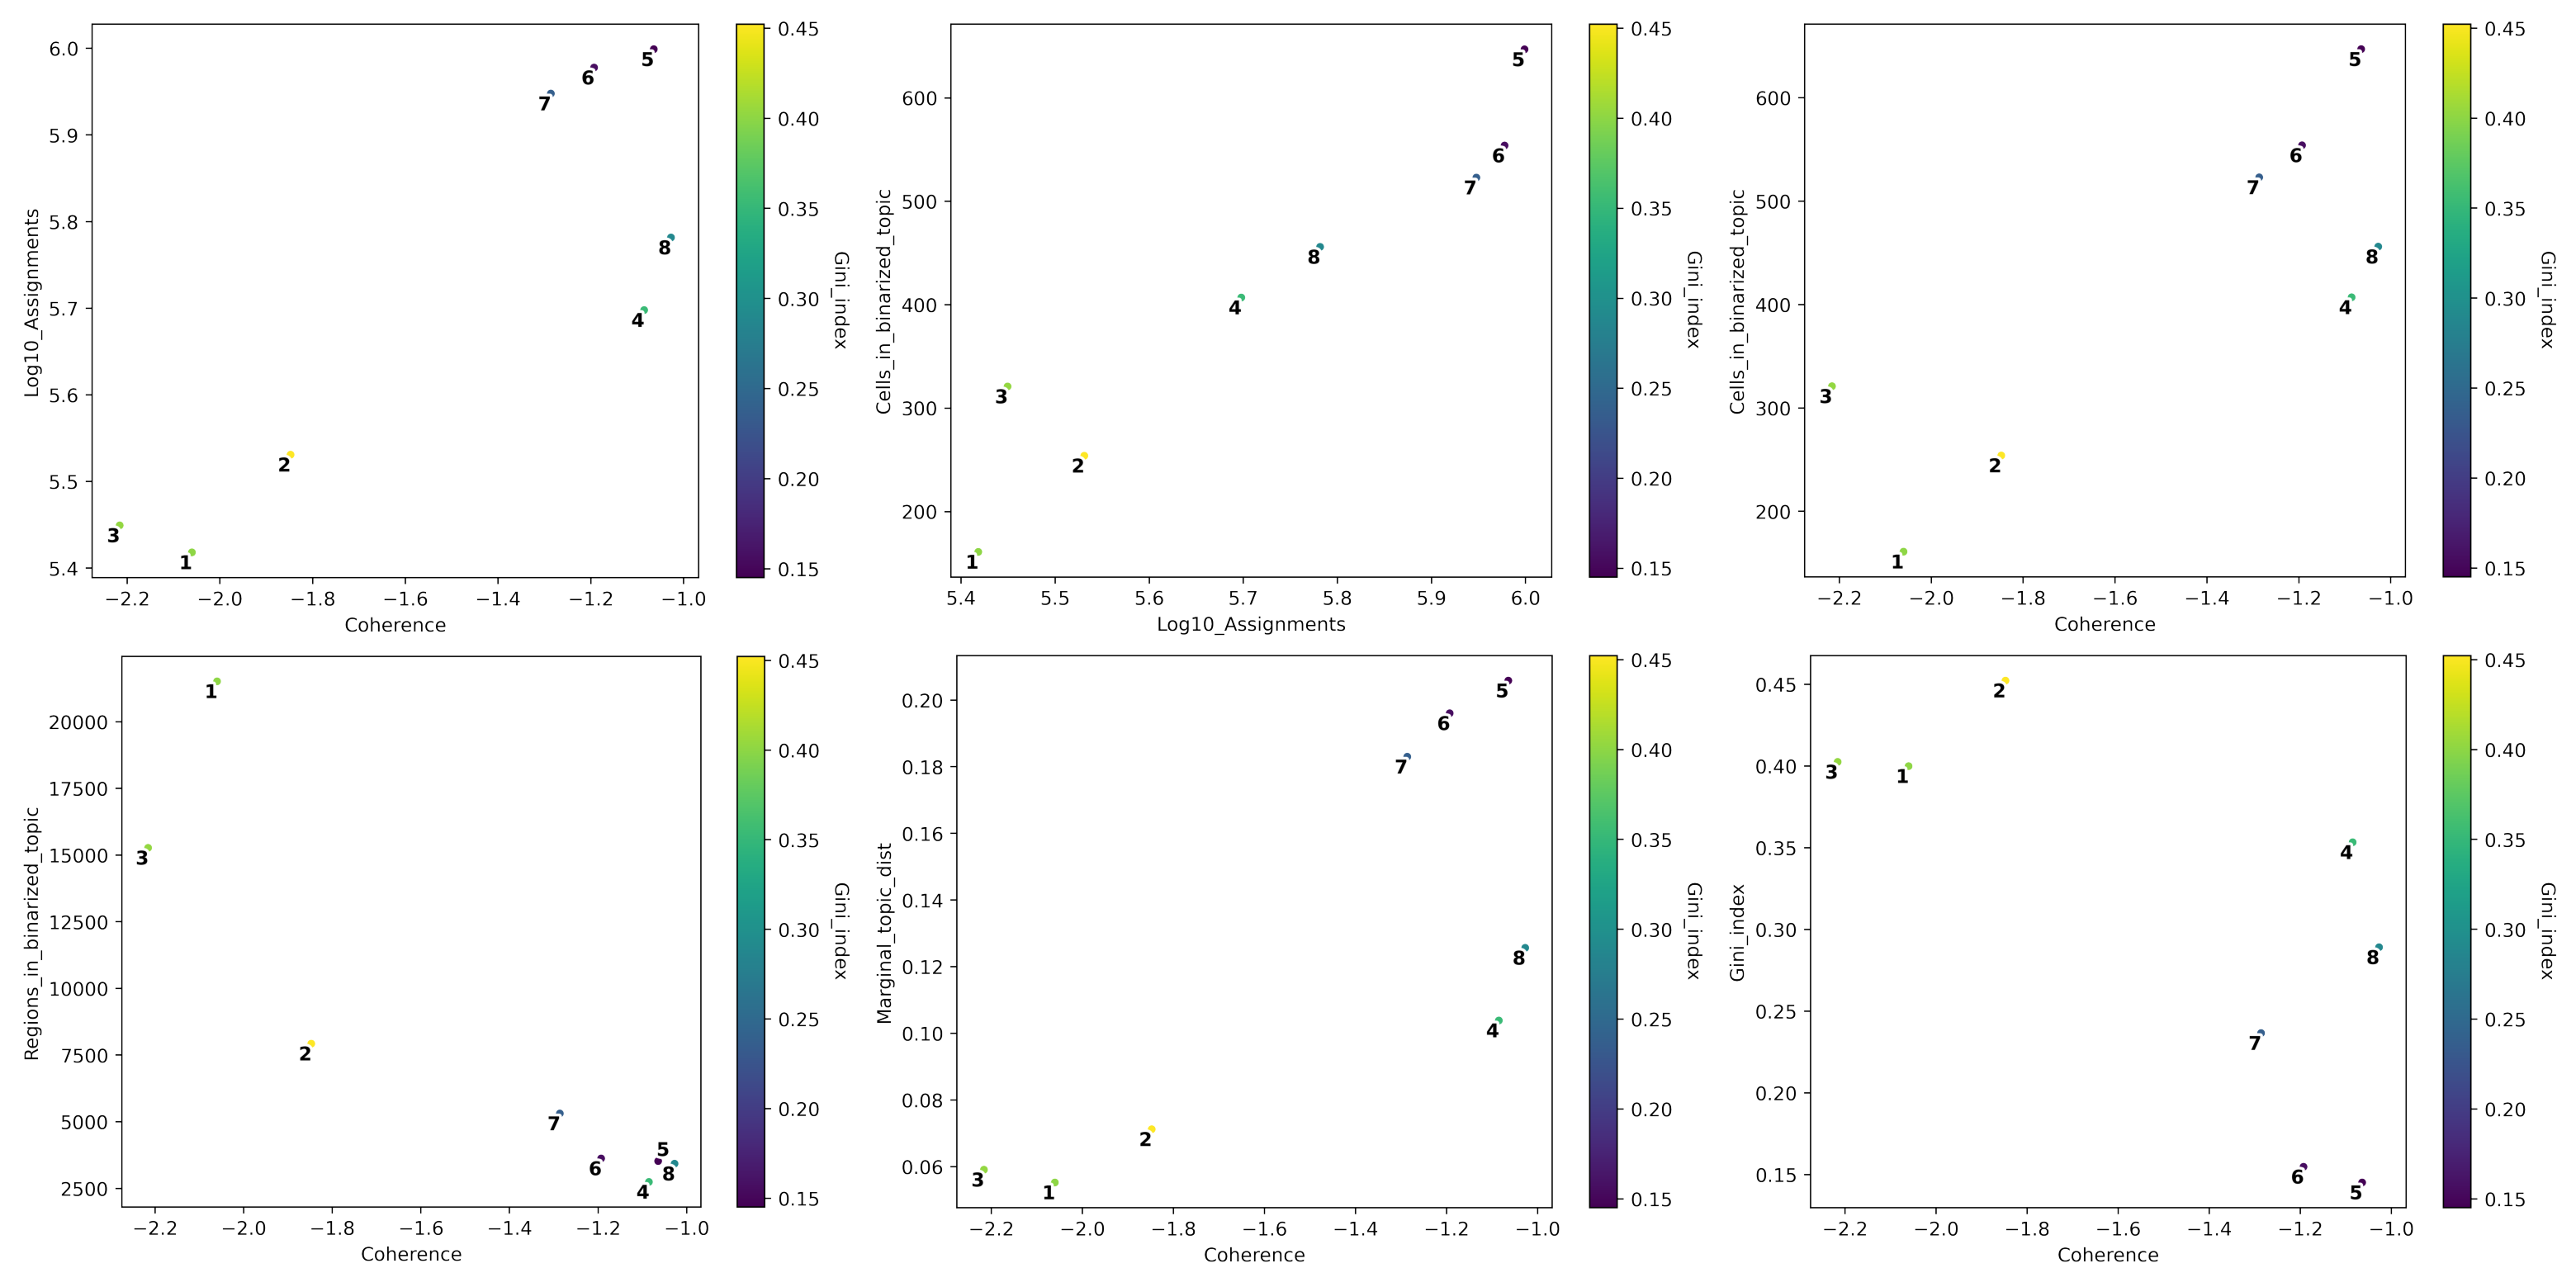

In [33]:
# Plot topic stats in one figure
fig=plt.figure(figsize=(40, 43))
i = 1
for fig_ in fig_dict.keys():
    plt.subplot(2, 3, i)
    img = fig2img(fig_dict[fig_]) #To convert figures to png to plot together, see .utils.py. This converts the figure to png.
    plt.imshow(img)
    plt.axis('off')
    i += 1
plt.subplots_adjust(wspace=0, hspace=-0.70)
plt.show()

In [ ]:
# continue working with topics that have a coherence value > -2.00, that will remove those topics that are in the low quality cells

# 4 compute DARs

In [53]:
from pycisTopic.diff_features import (
    impute_accessibility,
    normalize_scores,
    find_highly_variable_features,
    find_diff_features
)
import numpy as np

In [54]:
imputed_acc_obj = impute_accessibility(
    cistopic_obj,
    selected_cells=None,
    selected_regions=None,
    scale_factor=10**6
)

2026-01-06 15:36:22,906 cisTopic     INFO     Imputing region accessibility
2026-01-06 15:36:22,907 cisTopic     INFO     Impute region accessibility for regions 0-20000
2026-01-06 15:36:23,026 cisTopic     INFO     Impute region accessibility for regions 20000-40000
2026-01-06 15:36:23,138 cisTopic     INFO     Impute region accessibility for regions 40000-60000
2026-01-06 15:36:23,250 cisTopic     INFO     Impute region accessibility for regions 60000-80000
2026-01-06 15:36:23,363 cisTopic     INFO     Impute region accessibility for regions 80000-100000
2026-01-06 15:36:23,477 cisTopic     INFO     Impute region accessibility for regions 100000-120000
2026-01-06 15:36:23,591 cisTopic     INFO     Impute region accessibility for regions 120000-140000
2026-01-06 15:36:23,711 cisTopic     INFO     Impute region accessibility for regions 140000-160000
2026-01-06 15:36:23,831 cisTopic     INFO     Impute region accessibility for regions 160000-180000
2026-01-06 15:36:23,950 cisTopic     

In [55]:
variable = 'G'
outDir = '/staging/leuven/stg_00171/Mark/IX_XII_MP_integration/paper_subsets/'

import pickle
import os
pickle.dump(imputed_acc_obj,
            open(os.path.join(outDir, f"imputed_acc_obj_{variable}.pkl"), "wb"))

In [56]:
variable = 'G'
outDir = '/staging/leuven/stg_00171/Mark/IX_XII_MP_integration/paper_subsets/'

import pickle
import os
pickle.dump(cistopic_obj,
            open(os.path.join(outDir, f"{variable}_cistopic_obj_subset.pkl"), "wb"))

2026-01-06 15:36:40,524 cisTopic     INFO     Calculating mean
2026-01-06 15:36:40,798 cisTopic     INFO     Calculating variance


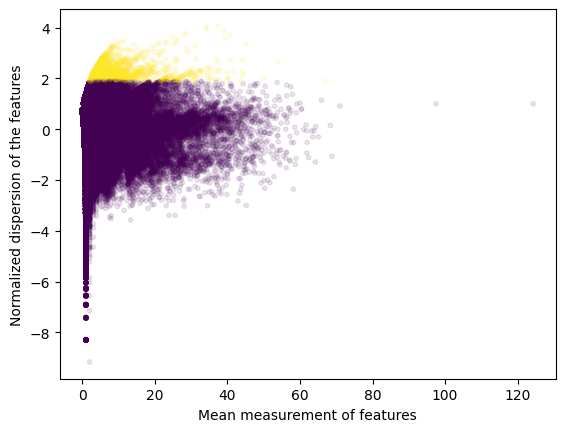

2026-01-06 15:36:50,184 cisTopic     INFO     Done!


In [57]:
variable_regions = find_highly_variable_features(
    imputed_acc_obj,
    min_disp = 0.05,
    min_mean = 0.0125,
    max_mean = 3,
    max_disp = np.inf,
    n_bins=20,
    n_top_features=2000,     # work only with top 2000 differentially accesible DARs
    plot=True
)

In [58]:
markers_dict = find_diff_features(
    cistopic_obj,
    imputed_acc_obj,
    variable='pycisTopic_leiden_10_0.1',
    var_features=variable_regions,
    contrasts=None,
    adjpval_thr=0.05,
    log2fc_thr=np.log2(1.5),
    n_cpu=5,
    #_temp_dir='/scratch/leuven/330/vsc33053/ray_spill',
    split_pattern = '-'
)

variable = 'G'
outDir = '/staging/leuven/stg_00171/Mark/IX_XII_MP_integration/paper_subsets/'
pickle.dump(markers_dict,
            open(os.path.join(outDir,f"markers_dict_leiden0.1_{variable}.pkl"), "wb"))

2026-01-06 15:37:18,039	INFO worker.py:1724 -- Started a local Ray instance.


2026-01-06 15:37:18,546 cisTopic     INFO     Subsetting data for GLIA(0) (1019 of 1366)
2026-01-06 15:37:21,518 cisTopic     INFO     Computing p-value for GLIA(0)
2026-01-06 15:37:23,573 cisTopic     INFO     Computing log2FC for GLIA(0)
2026-01-06 15:37:24,817 cisTopic     INFO     GLIA(0) done!
2026-01-06 15:37:24,818 cisTopic     INFO     Subsetting data for GLIA(1) (274 of 1366)
2026-01-06 15:37:24,824 cisTopic     INFO     Computing p-value for GLIA(1)
2026-01-06 15:37:25,526 cisTopic     INFO     Computing log2FC for GLIA(1)
2026-01-06 15:37:25,529 cisTopic     INFO     GLIA(1) done!
2026-01-06 15:37:25,530 cisTopic     INFO     Subsetting data for GLIA(2) (73 of 1366)
2026-01-06 15:37:25,531 cisTopic     INFO     Computing p-value for GLIA(2)
2026-01-06 15:37:26,230 cisTopic     INFO     Computing log2FC for GLIA(2)
2026-01-06 15:37:26,242 cisTopic     INFO     GLIA(2) done!


In [59]:
from pycisTopic.clust_vis import plot_imputed_features

In [61]:
marker_list = [markers_dict[x].index.tolist()[0] for x in ['GLIA(0)', 'GLIA(1)', 'GLIA(2)']]

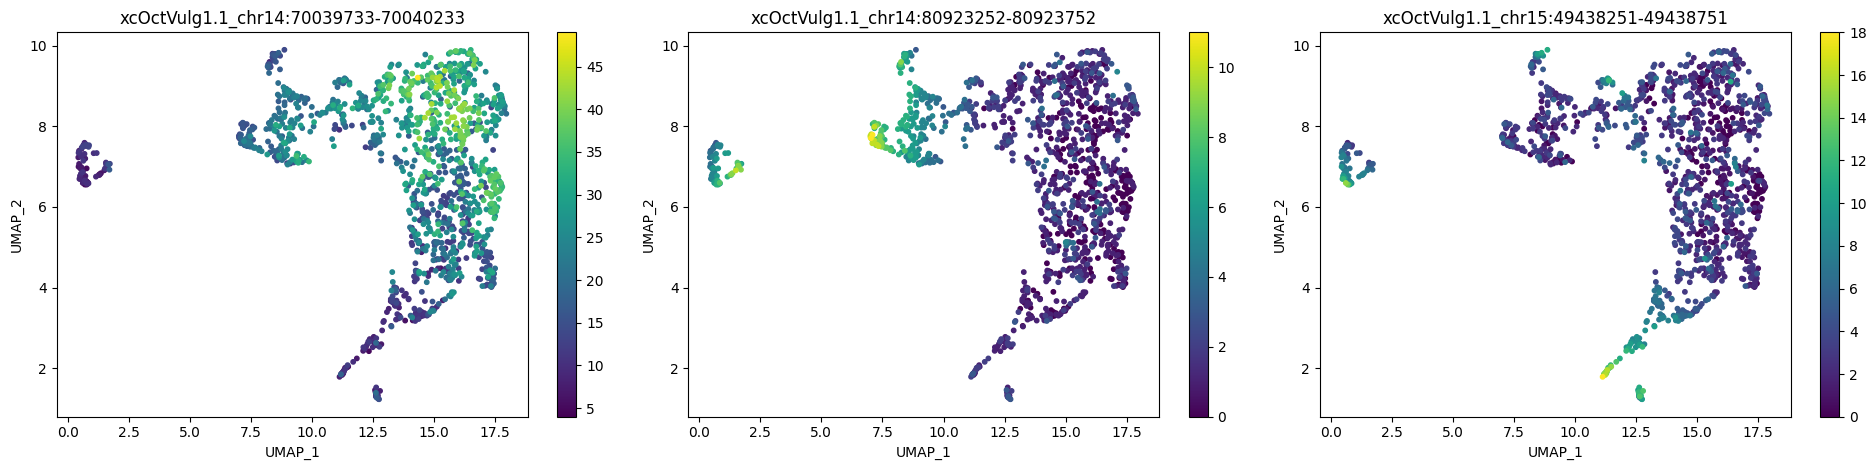

In [62]:
plot_imputed_features(
    cistopic_obj,
    reduction_name='UMAP_HARM',
    imputed_data=imputed_acc_obj,
    features=marker_list,
    scale=False,
    num_columns=4
)

# 5 save regions set for G

In [64]:
variable='G'
outDir = '/staging/leuven/stg_00171/Mark/IX_XII_MP_integration/paper_subsets/'

os.makedirs(os.path.join(outDir, f"region_sets_{variable}"), exist_ok = True)
os.makedirs(os.path.join(outDir, f"region_sets_{variable}", "Topics_otsu"), exist_ok = True)
os.makedirs(os.path.join(outDir, f"region_sets_{variable}", "Topics_top_2k"), exist_ok = True)
os.makedirs(os.path.join(outDir, f"region_sets_{variable}", f"DARs_{variable}_leiden0.1"), exist_ok = True)

In [65]:
from pycisTopic.utils import region_names_to_coordinates

In [66]:
for topic in region_bin_topics_otsu:
    region_names_to_coordinates(
        region_bin_topics_otsu[topic].index
    ).sort_values(
        ["Chromosome", "Start", "End"]
    ).to_csv(
        os.path.join(outDir, f"region_sets_{variable}", "Topics_otsu", f"{topic}.bed"),
        sep = "\t",
        header = False, index = False
    )

In [67]:
for topic in region_bin_topics_top_2k:
    region_names_to_coordinates(
        region_bin_topics_top_2k[topic].index
    ).sort_values(
        ["Chromosome", "Start", "End"]
    ).to_csv(
        os.path.join(outDir, f"region_sets_{variable}", "Topics_top_2k", f"{topic}.bed"),
        sep = "\t",
        header = False, index = False
    )

In [68]:
for cell_type in markers_dict:
    region_names_to_coordinates(
        markers_dict[cell_type].index
    ).sort_values(
        ["Chromosome", "Start", "End"]
    ).to_csv(
        os.path.join(outDir, f"region_sets_{variable}", f"DARs_{variable}_leiden0.1", f"{cell_type}.bed"),
        sep = "\t",
        header = False, index = False
    )

# 6 plotting

In [1]:
import pickle
outDir = '/staging/leuven/stg_00171/Mark/IX_XII_MP_integration/paper_subsets/'
infile = open(outDir + "G_cistopic_obj_subset.pkl", 'rb')
cistopic_obj = pickle.load(infile)
infile.close()

In [9]:
from pycisTopic.clust_vis import (
    find_clusters,
    run_umap,
    run_tsne,
    plot_metadata,
    plot_topic,
    cell_topic_heatmap
)

In [3]:
cistopic_obj.cell_data['batch'] = cistopic_obj.cell_data['sample_id']
cistopic_obj.cell_data['batch'] = cistopic_obj.cell_data['batch'].str.replace('_1', '')
cistopic_obj.cell_data['batch'] = cistopic_obj.cell_data['batch'].str.replace('_2', '')
cistopic_obj.cell_data['batch'] = cistopic_obj.cell_data['batch'].str.replace('_3', '')

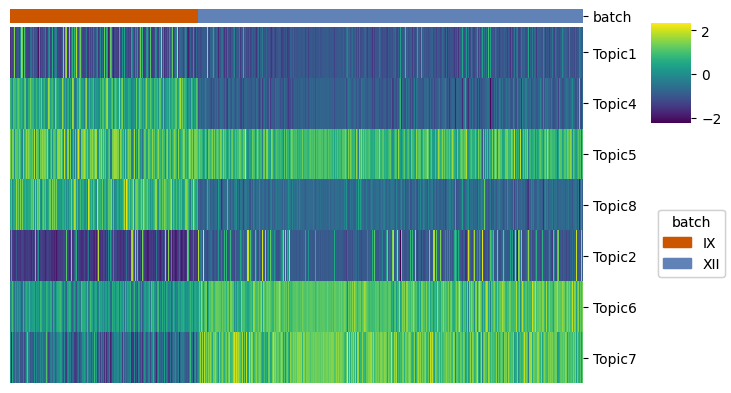

In [14]:
good_topics = [1,2,4,5,6,7,8]

color_dic = {'batch':
                 {
                     'IX': '#CC5500',
                     'XII': '#6082B6'
                 }
                }

cell_topic_heatmap(
    cistopic_obj,
    variables = ['batch'],
    scale = True,
    legend_loc_x = 1.0,
    legend_loc_y = -1.2,
    legend_dist_y = -1,
    selected_topics=good_topics,
    color_dictionary=color_dic,
    figsize = (8, 5),
    save='figures/paper/Figure 6/cell_topic_heatmap_G_good_topics_batch.pdf'
)


In [6]:
good_topics = [1,2,4,5,6,7,8]

run_umap(
    cistopic_obj,
    target  = 'cell', scale=True, 
    reduction_name = 'UMAP_HARM',
    harmony=True,
    verbose=False,
    selected_topics=good_topics
)

2026-01-23 10:57:38,868 cisTopic     INFO     Running UMAP


/data/leuven/347/vsc34794/miniconda3/envs/scenicplus/lib/python3.11/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


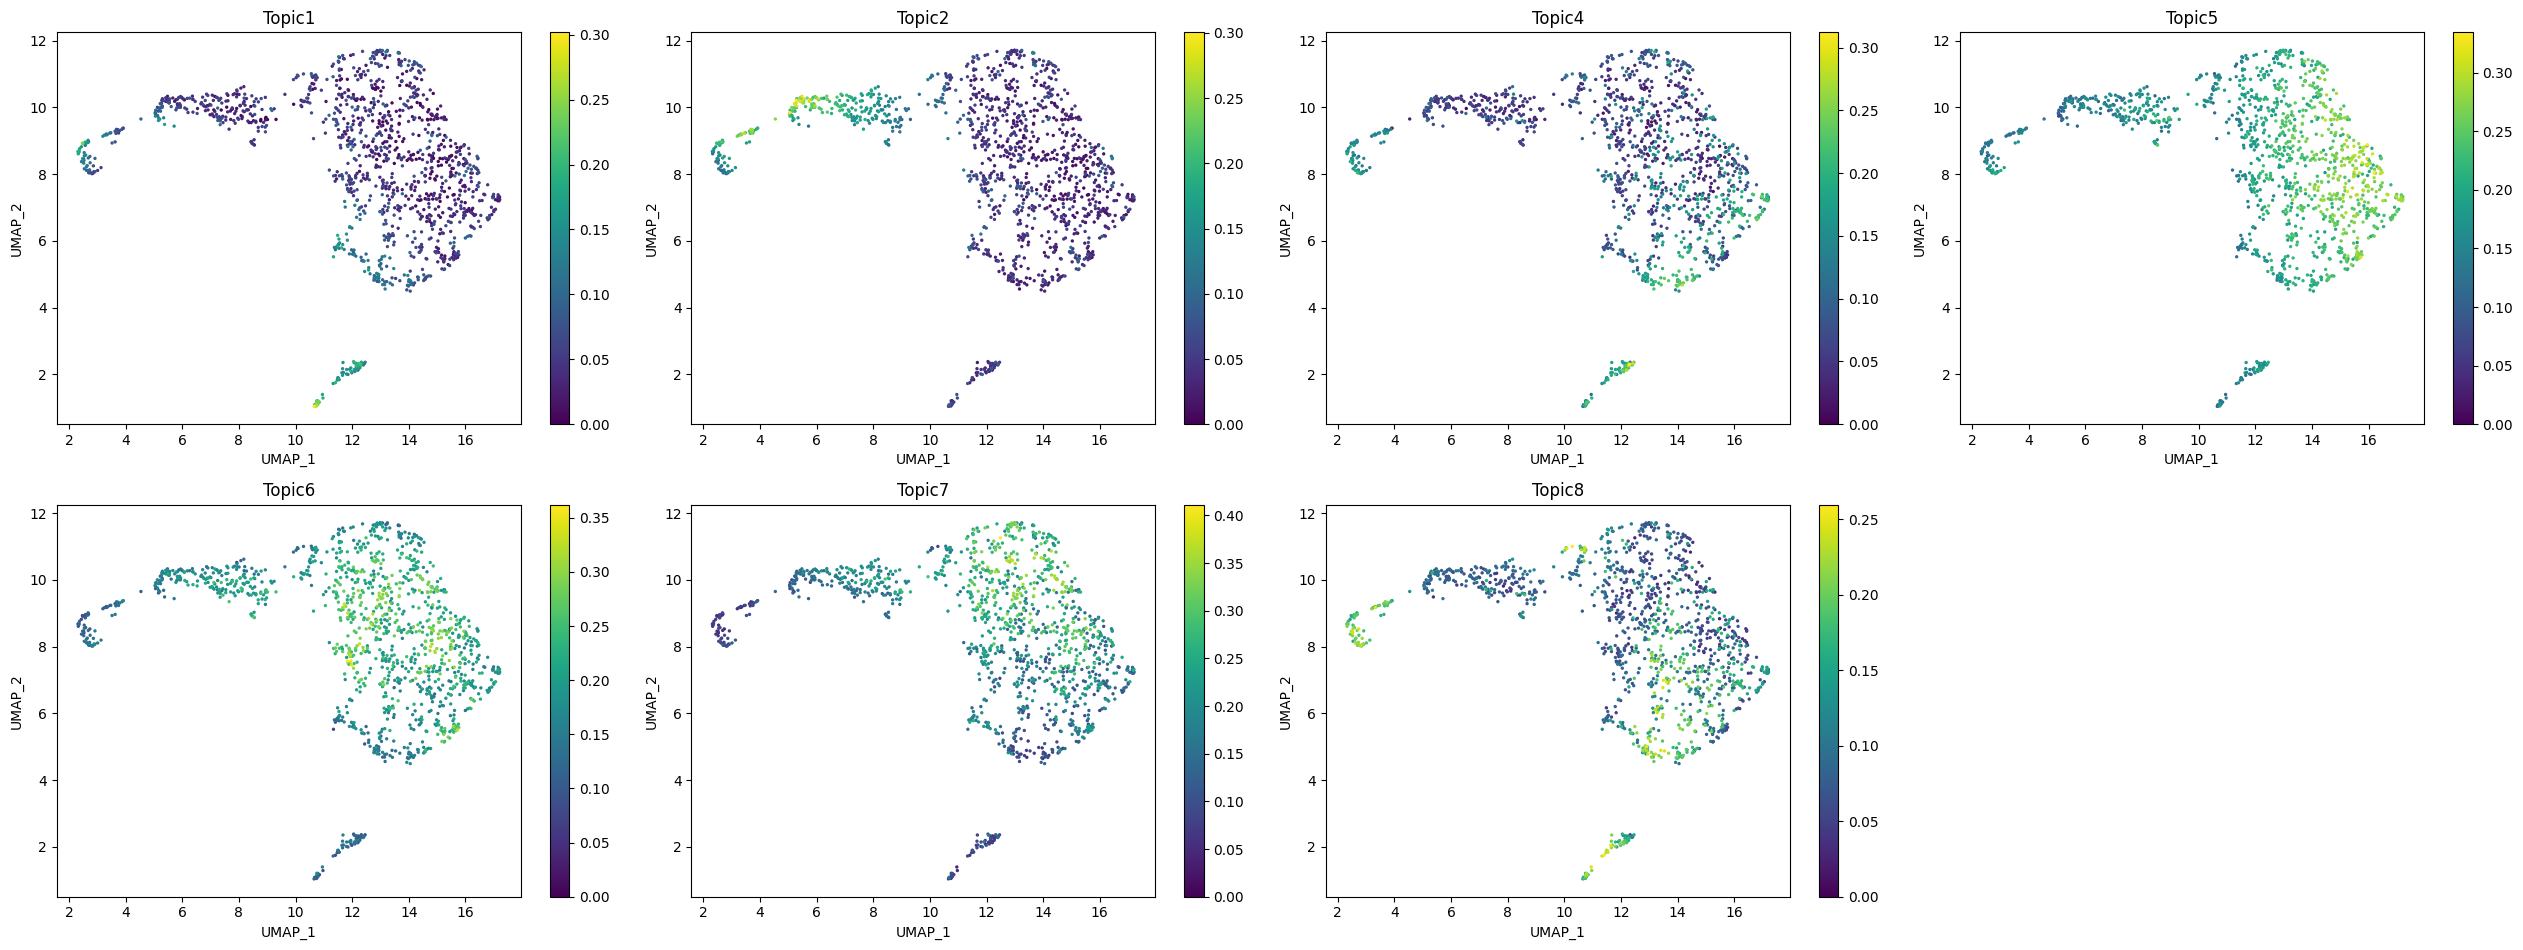

In [12]:
good_topics = [1,2,4,5,6,7,8]

plot_topic(
    cistopic_obj,
    reduction_name = 'UMAP_HARM',
    target = 'cell',
    num_columns=4,
    dot_size=2,
    cmap='viridis',
    selected_topics=good_topics,
    save='figures/paper/Figure 6/plot_topic_G_qc.pdf'
)

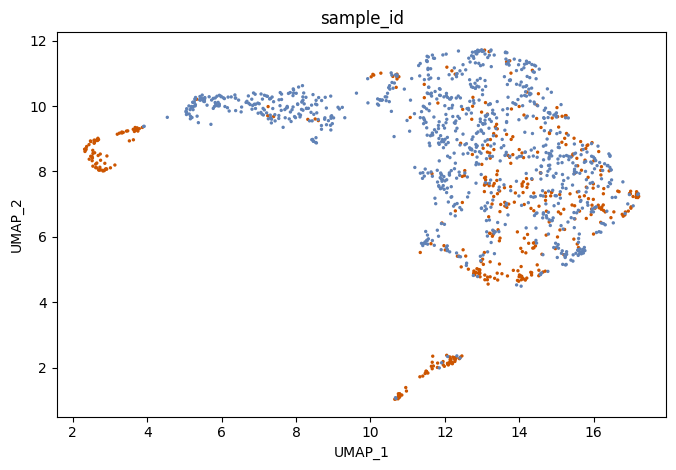

In [11]:
color_dic = {'ATAC_coarse': {
                'MES': '#E3735E',
                'EPI': '#235a5a',
                'GLIA': '#770737',
                'NPROG': '#4a7c99',
                'NDIFF': '#93C572',
                'RET': '#F3CFC6',
                'ENDO': '#eeaf61'
            },
             'sample_id': 
             {
                 'IX_1': '#CC5500',
                 'IX_2': '#CC5500',
                 'XII_1': '#6082B6',
                 'XII_2': '#6082B6',
                 'XII_3': '#6082B6'
             }
            }


plot_metadata(
    cistopic_obj,
    reduction_name='UMAP_HARM',
    variables=['sample_id'],
    target='cell', num_columns=4,
    text_size=10,
    color_dictionary=color_dic,
    show_label=False,
    dot_size=2,
    save='figures/paper/Figure 6/UMAP_G_qc_batch.pdf'
)

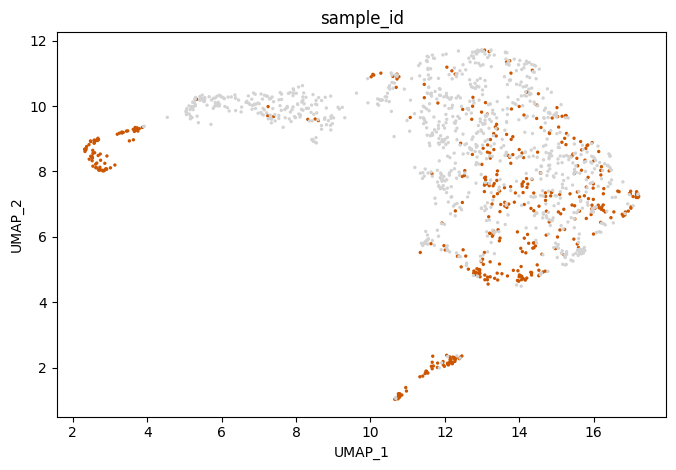

In [9]:
color_dic = {'ATAC_coarse': {
                'MES': '#E3735E',
                'EPI': '#235a5a',
                'GLIA': '#770737',
                'NPROG': '#4a7c99',
                'NDIFF': '#93C572',
                'RET': '#F3CFC6',
                'ENDO': '#eeaf61'
            },
             'sample_id': 
             {
                 'IX_1': '#CC5500',
                 'IX_2': '#CC5500',
                 'XII_1': '#6082B6',
                 'XII_2': '#6082B6',
                 'XII_3': '#6082B6'
             }
            }

highlight_dic = {'sample_id':
                 {
                     'IX_1': '#CC5500',
                     'IX_2': '#CC5500',
                     'XII_1': '#D3D3D3',
                     'XII_2': '#D3D3D3',
                     'XII_3': '#D3D3D3'
                 }
                }


plot_metadata(
    cistopic_obj,
    reduction_name='UMAP_HARM',
    variables=['sample_id'],
    target='cell', num_columns=4,
    text_size=10,
    color_dictionary=highlight_dic,
    show_label=False,
    dot_size=2,
    save='figures/paper/Figure 6/UMAP_G_qc_IX.png'
)

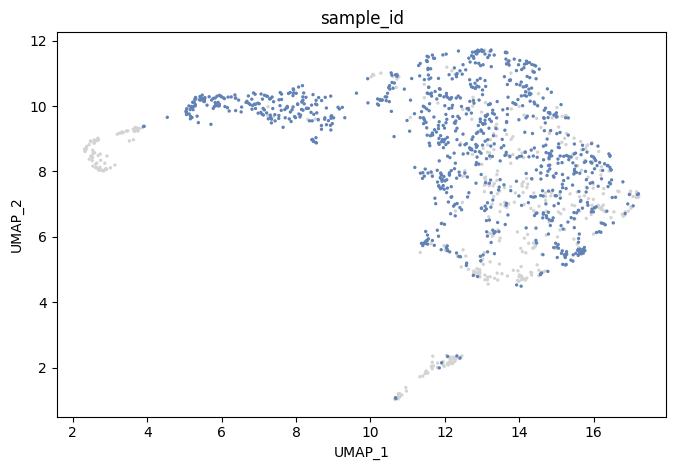

In [10]:
color_dic = {'ATAC_coarse': {
                'MES': '#E3735E',
                'EPI': '#235a5a',
                'GLIA': '#770737',
                'NPROG': '#4a7c99',
                'NDIFF': '#93C572',
                'RET': '#F3CFC6',
                'ENDO': '#eeaf61'
            },
             'sample_id': 
             {
                 'IX_1': '#CC5500',
                 'IX_2': '#CC5500',
                 'XII_1': '#6082B6',
                 'XII_2': '#6082B6',
                 'XII_3': '#6082B6'
             }
            }

highlight_dic = {'sample_id':
                 {
                     'IX_1': '#D3D3D3',
                     'IX_2': '#D3D3D3',
                     'XII_1': '#6082B6',
                     'XII_2': '#6082B6',
                     'XII_3': '#6082B6'
                 }
                }


plot_metadata(
    cistopic_obj,
    reduction_name='UMAP_HARM',
    variables=['sample_id'],
    target='cell', num_columns=4,
    text_size=10,
    color_dictionary=highlight_dic,
    show_label=False,
    dot_size=2,
    save='figures/paper/Figure 6/UMAP_G_qc_XII.png'
)

# 7 plotting with scenicplus glia annotation

In [2]:
import scanpy as sc
outDir = '/staging/leuven/stg_00171/Mark/IX_XII_MP_integration/pycistopic_papero/bc_subset_output/scenicplus_out/'
eRegulon_gene_AUC_sub = sc.read_h5ad(outDir + 'eRegulon_gene_AUC_sub_G.h5ad')

In [3]:
cistopic_obj.cell_data['glia_sub_anno'] = eRegulon_gene_AUC_sub.obs['glia_sub_anno']

In [4]:
cistopic_obj.cell_data['glia_sub_anno'] 

CGCGGATTCGAGCAAA-1-IX_1___IX_1          NaN
CGAAGCGAGCTGGCTA-1-IX_1___IX_1          NaN
CCCAAATAGGACTTAC-1-IX_1___IX_1          NaN
TCCATATTCATGTCAA-1-IX_1___IX_1      glial_2
CAGGTTTAGTAATCCA-1-IX_1___IX_1          NaN
                                     ...   
ATGATGACAGGATAAC-1-XII_3___XII_3    glial_1
TTGTGTGCAATTGCGC-1-XII_3___XII_3        NaN
GATTATGTCATAACCA-1-XII_3___XII_3    glial_1
ACTGAAACAAGGAATC-1-XII_3___XII_3        NaN
GAGCAAGGTACGATTG-1-XII_3___XII_3    glial_1
Name: glia_sub_anno, Length: 1366, dtype: category
Categories (3, object): ['glial_1', 'glial_2', 'glial_3']

In [5]:
variable = 'glia_sub_anno'

annot_dict = {}
for resolution in [0.1, 0.2, 0.3, 0.4, 0.5]:
    annot_dict[f"pycisTopic_leiden_10_{resolution}"] = {}
    for cluster in set(cistopic_obj.cell_data[f"pycisTopic_leiden_10_{resolution}"]):
        counts = cistopic_obj.cell_data.loc[
            cistopic_obj.cell_data.loc[cistopic_obj.cell_data[f"pycisTopic_leiden_10_{resolution}"] == cluster].index,
            variable].value_counts()
        annot_dict[f"pycisTopic_leiden_10_{resolution}"][cluster] = f"{counts.index[counts.argmax()]}({cluster})"



In [6]:
for resolution in [0.1, 0.2, 0.3, 0.4, 0.5]:
    cistopic_obj.cell_data[f'pycisTopic_leiden_10_{resolution}'] = [
        annot_dict[f'pycisTopic_leiden_10_{resolution}'][x] for x in cistopic_obj.cell_data[f'pycisTopic_leiden_10_{resolution}'].tolist()
    ]


In [7]:
cistopic_obj.cell_data['pycisTopic_leiden_10_0.1'].values

array(['glial_3(GLIA(2))', 'glial_2(GLIA(1))', 'glial_1(GLIA(0))', ...,
       'glial_1(GLIA(0))', 'glial_1(GLIA(0))', 'glial_1(GLIA(0))'],
      dtype=object)

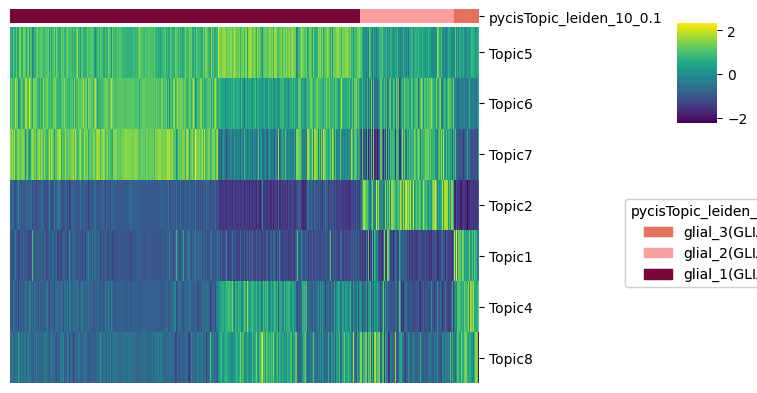

In [38]:
good_topics = [1,2,4,5,6,7,8]

color_dic = {'pycisTopic_leiden_10_0.1':
                 {
                     'glial_3(GLIA(2))': '#E3735E',
                     'glial_2(GLIA(1))': '#FAA0A0',
                     'glial_1(GLIA(0))': '#770737'
                 }
                }


cell_topic_heatmap(
    cistopic_obj,
    variables = ['pycisTopic_leiden_10_0.1'],
    scale = True,
    legend_loc_x = 1.0,
    legend_loc_y = -1.2,
    legend_dist_y = -1,
    selected_topics=good_topics,
    color_dictionary=color_dic,
    figsize = (8, 5),
    save='figures/paper/Figure 6/cell_topic_heatmap_G_good_topics_pycisTopic_leiden_10_0.1.pdf'
)


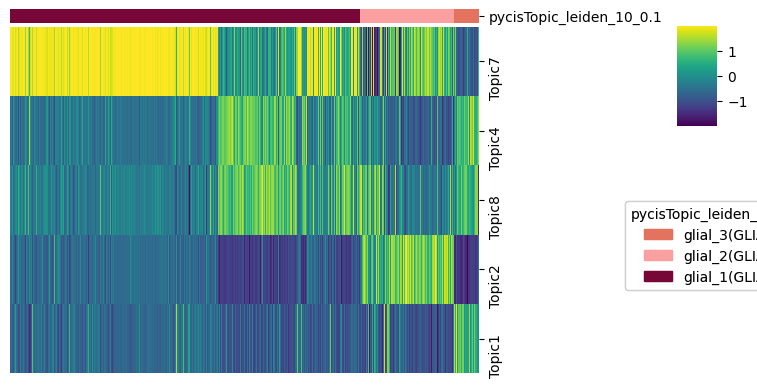

In [23]:
good_topics = [1,2,4,7,8]

color_dic = {'pycisTopic_leiden_10_0.1':
                 {
                     'glial_3(GLIA(2))': '#E3735E',
                     'glial_2(GLIA(1))': '#FAA0A0',
                     'glial_1(GLIA(0))': '#770737'
                 }
                }


cell_topic_heatmap(
    cistopic_obj,
    variables = ['pycisTopic_leiden_10_0.1'],
    scale = True,
    cluster_topics=True,
    legend_loc_x = 1.0,
    legend_loc_y = -1.2,
    legend_dist_y = -1,
    selected_topics=good_topics,
    color_dictionary=color_dic,
    figsize = (8, 5),
    save='figures/paper/Figure 6/cell_topic_heatmap_G_topics_1_2_4_7_8_pycisTopic_leiden_10_0.1.pdf'
)


In [16]:
cistopic_obj.cell_data['batch_id'] = cistopic_obj.cell_data['sample_id']
cistopic_obj.cell_data['batch_id'] = cistopic_obj.cell_data['batch_id'].str.replace('_1', '')
cistopic_obj.cell_data['batch_id'] = cistopic_obj.cell_data['batch_id'].str.replace('_2', '')
cistopic_obj.cell_data['batch_id'] = cistopic_obj.cell_data['batch_id'].str.replace('_3', '')
cistopic_obj.cell_data['batch_id']

CGCGGATTCGAGCAAA-1-IX_1___IX_1       IX
CGAAGCGAGCTGGCTA-1-IX_1___IX_1       IX
CCCAAATAGGACTTAC-1-IX_1___IX_1       IX
TCCATATTCATGTCAA-1-IX_1___IX_1       IX
CAGGTTTAGTAATCCA-1-IX_1___IX_1       IX
                                   ... 
ATGATGACAGGATAAC-1-XII_3___XII_3    XII
TTGTGTGCAATTGCGC-1-XII_3___XII_3    XII
GATTATGTCATAACCA-1-XII_3___XII_3    XII
ACTGAAACAAGGAATC-1-XII_3___XII_3    XII
GAGCAAGGTACGATTG-1-XII_3___XII_3    XII
Name: batch_id, Length: 1366, dtype: object

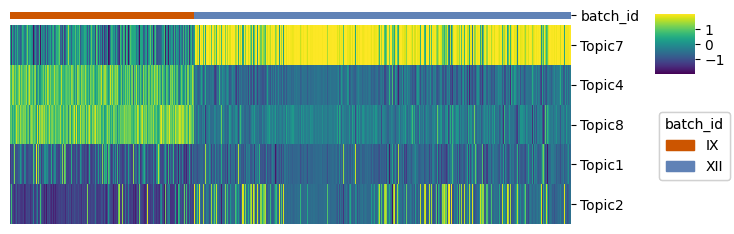

In [22]:
good_topics = [1,2,4,8,7]

color_dic = {'batch_id':
                 {
                     'IX': '#CC5500',
                     'XII': '#6082B6'
                 }
                }

cell_topic_heatmap(
    cistopic_obj,
    variables = ['batch_id'],
    cluster_topics=True,
    scale = True,
    legend_loc_x = 1.0,
    legend_loc_y = -1.2,
    legend_dist_y = -1,
    selected_topics=good_topics,
    color_dictionary=color_dic,
    figsize = (8, 3),
    save='figures/paper/Figure 6/cell_topic_heatmap_G_topics_1_2_4_7_8_batch.pdf'
)


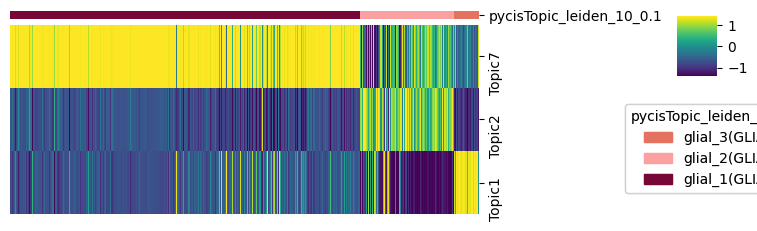

In [45]:
good_topics = [1,2,7]

color_dic = {'pycisTopic_leiden_10_0.1':
                 {
                     'glial_3(GLIA(2))': '#E3735E',
                     'glial_2(GLIA(1))': '#FAA0A0',
                     'glial_1(GLIA(0))': '#770737'
                 }
                }


cell_topic_heatmap(
    cistopic_obj,
    variables = ['pycisTopic_leiden_10_0.1'],
    scale = True,
    legend_loc_x = 1.0,
    legend_loc_y = -1.2,
    legend_dist_y = -1,
    selected_topics=good_topics,
    color_dictionary=color_dic,
    figsize = (8, 3),
    save='figures/paper/Figure 6/cell_topic_heatmap_G_topics_1_2_7_pycisTopic_leiden_10_0.1.pdf'
)


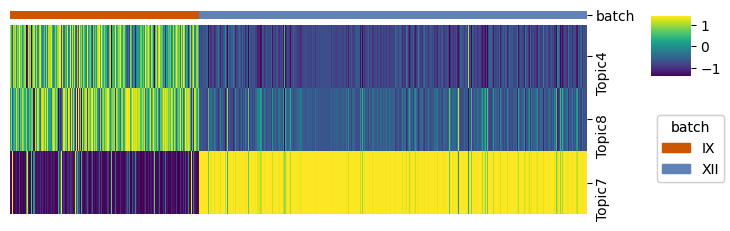

In [44]:
good_topics = [4,8,7]

color_dic = {'batch':
                 {
                     'IX': '#CC5500',
                     'XII': '#6082B6'
                 }
                }

cell_topic_heatmap(
    cistopic_obj,
    variables = ['batch'],
    scale = True,
    legend_loc_x = 1.0,
    legend_loc_y = -1.2,
    legend_dist_y = -1,
    selected_topics=good_topics,
    color_dictionary=color_dic,
    figsize = (8, 3),
    save='figures/paper/Figure 6/cell_topic_heatmap_G_topics_4_7_8_batch.pdf'
)


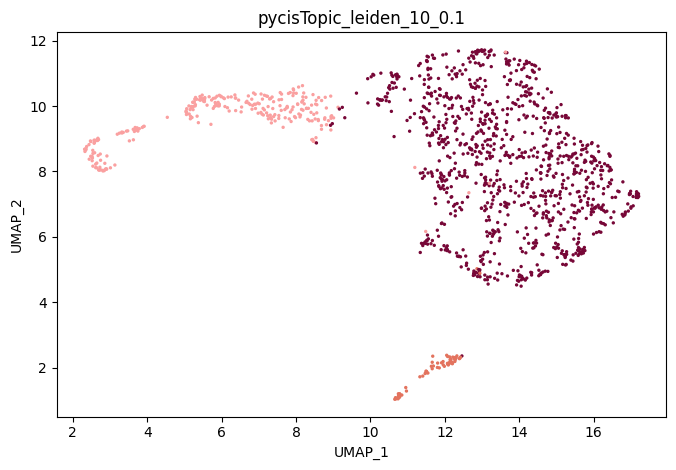

In [37]:
color_dic = {'pycisTopic_leiden_10_0.1':
                 {
                     'glial_3(GLIA(2))': '#E3735E',
                     'glial_2(GLIA(1))': '#FAA0A0',
                     'glial_1(GLIA(0))': '#770737'
                 }
                }

plot_metadata(
    cistopic_obj,
    reduction_name='UMAP_HARM',
    variables=['pycisTopic_leiden_10_0.1'],
    target='cell', num_columns=4,
    text_size=10,
    color_dictionary=color_dic,
    show_label=False,
    dot_size=2,
    save='figures/paper/Figure 6/UMAP_G_pycisTopic_leiden_10_0.1.pdf'
)

In [13]:
variable = 'G'
outDir = '/staging/leuven/stg_00171/Mark/IX_XII_MP_integration/paper_subsets/'

import pickle
import os
pickle.dump(cistopic_obj,
            open(os.path.join(outDir, f"{variable}_cistopic_obj_subset_UMAP_RED.pkl"), "wb"))